In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [14]:
data = pd.read_csv('/content/olist_customers_dataset.csv')

In [15]:
df = pd.DataFrame(data)
df

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS


### There are almost '99441' Customers

In [ ]:
df['customer_id'].nunique()

99441

### unique_id_column has Duplicate Instances -- customer_id has not

In [ ]:
df[df['customer_unique_id'].duplicated()]

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
679,c57b4b6f3719475543b721e720a526ad,b6c083700ca8c135ba9f0f132930d4e8,8686,suzano,SP
1463,9f6f3da49e2d46e3a7529f5e3c25ecce,a40096fc0a3862e9e12bc55b5f8e6ab2,20561,rio de janeiro,RJ
1607,299f7b5125c8fbe1761a1b320c34fc7d,b8b3c435a58aebd788a477bed8342910,95585,arroio do sal,RS
2811,226d59f9f4b98e228b689eea45d03a6d,66980c3775537536f77b434d74e520f5,30290,belo horizonte,MG
3198,b1253701171dfb298f52a221f824e45b,788313d21c3507fe890921f6e17aa679,11070,santos,SP
...,...,...,...,...,...
99324,5b46a0d983eec8c97363bea78d4a69dd,8bab3162259edfaadd1ea2e1fe7f58dc,31565,belo horizonte,MG
99327,c1affa46f9f3b514555259049a0307b9,12ab9334b1240d6d037f2b0102a49571,38050,uberaba,MG
99336,ebf46ff530343a129926adc1f831dea4,0ee57f62666561b72f2ceacad0230cbf,9530,sao caetano do sul,SP
99353,282fbce48e4d2077aad602dd125c9225,0ceb502fc33a2ad327b08288c5310e2e,29134,viana,ES


### There are Total 4119 Unique Cities Customers Belonged from.

In [ ]:
print(list(df['customer_city'].unique())) # To view all if there are Many.
print(len(df['customer_city'].unique())) # To Count number of Unique Ones.
df['customer_city'].nunique() # To Count number of Unique Ones.  "SAME"


4119


### There are no Null Values in our Data Set.

In [ ]:
print(df['customer_state'].isna().sum())
print(df['customer_city'].isna().sum())
print(df['customer_zip_code_prefix'].isna().sum())
df[df['customer_unique_id'].isna()] # To View Actual Rows


0
0
0


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state


### There are no Null Values in Customer Table

In [ ]:
nulls_cust = df[df.isna().any(axis=1)]
print(nulls_cust)

Empty DataFrame
Columns: [customer_id, customer_unique_id, customer_zip_code_prefix, customer_city, customer_state]
Index: []


# Orders

In [16]:
data_ord = pd.read_csv('/content/olist_orders_dataset.csv')
df_ord = pd.DataFrame(data_ord)
df_ord

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


### Here is the Thing how Can I Join these Two Tables for Analysis

### Number of Orders

In [ ]:
df_ord['order_id'].nunique() # 99441

99441

### Column Types

In [ ]:
Numerical_cols = df_ord.select_dtypes(include=['number']).columns
Categorical_cols = df_ord.select_dtypes(include=['object','category']).columns
Date_cols = df_ord.select_dtypes(include=['datetime64']).columns
print("Numerical",Numerical_cols)
print("Cateorical",Categorical_cols)
print("Date_Time",Date_cols)

Numerical Index([], dtype='object')
Cateorical Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')
Date_Time Index([], dtype='object')


### Identifier Columns

In [ ]:
id_based_col = [col for col in df_ord if 'id' in col.lower()]
print(id_based_col)

['order_id', 'customer_id']


In [ ]:
len(df.columns)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


### No any customer Place More than 1 Order

In [ ]:
df_ord[df_ord['customer_id'].duplicated()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date


### There are Total 2980 Rows having Null Values


In [ ]:
nulls = df_ord[df_ord.isna().any(axis=1)]
print(nulls)

Empty DataFrame
Columns: [order_id, customer_id, order_status, order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date]
Index: []


### Now we have to fill Null Dates with Some Flags

In [ ]:
df_ord['order_delivered_carrier_date'] = df_ord['order_delivered_carrier_date'].fillna('1900-01-01')
df_ord['order_delivered_customer_date'] = df_ord['order_delivered_customer_date'].fillna('1900-01-01')
df_ord['order_approved_at'] = df_ord['order_approved_at'].fillna('1900-01-01')



# Products


In [ ]:
data_prod = pd.read_csv('olist_products_dataset.csv')
df_prod = pd.DataFrame(data_prod)

In [ ]:
df_prod

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [ ]:
df_prod['product_id'].nunique()

32951

In [ ]:
df_prod[df_prod.isna().any(axis=1)]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm


In [ ]:
df_prod['product_category_name'] = df_prod['product_category_name'].isna

### Now we have to Fill Nulls


In [ ]:
df_prod['product_category_name'] = df_prod['product_category_name'].fillna('unknown')
df_prod['product_name_lenght'] = df_prod['product_name_lenght'].fillna(0)
df_prod['product_photos_qty'] = df_prod['product_photos_qty'].fillna(0)
df_prod['product_description_lenght'] = df_prod['product_description_lenght'].fillna(0)

df_prod['product_weight_g'] = df_prod['product_weight_g'].fillna(0)
df_prod['product_length_cm'] = df_prod['product_length_cm'].fillna(0)
df_prod['product_height_cm'] = df_prod['product_height_cm'].fillna(0)
df_prod['product_width_cm'] = df_prod['product_width_cm'].fillna(0)



# Category Names Table

In [ ]:
data_cat = pd.read_csv('product_category_name_translation.csv')
df_cat = pd.DataFrame(data_cat)
df_cat

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
...,...,...
66,flores,flowers
67,artes_e_artesanato,arts_and_craftmanship
68,fraldas_higiene,diapers_and_hygiene
69,fashion_roupa_infanto_juvenil,fashion_childrens_clothes


# GEO_Location

In [ ]:
data_geo = pd.read_csv('olist_geolocation_dataset.csv')
df_geo = pd.DataFrame(data_geo)

In [ ]:
df_geo

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP
...,...,...,...,...,...
1000158,99950,-28.068639,-52.010705,tapejara,RS
1000159,99900,-27.877125,-52.224882,getulio vargas,RS
1000160,99950,-28.071855,-52.014716,tapejara,RS
1000161,99980,-28.388932,-51.846871,david canabarro,RS


In [ ]:
df_geo[df_geo.isna().any(axis=1)]

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state


# Order List Items

In [ ]:
data_items = pd.read_csv('olist_order_items_dataset.csv')
df_items = pd.DataFrame(data_items)


In [ ]:
df_items[df_items.isna().any(axis=1)]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value


# Orders Payment


In [4]:
data_rev = pd.read_csv('/olist_order_payments_dataset.csv')
df_rev = pd.DataFrame(data_rev)
df_rev

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


# One Hot Encoding

In [ ]:
df_rev = pd.get_dummies(df_rev,columns=['payment_type'],dtype=int)

In [ ]:
df_rev['payment_type'].unique()

array(['credit_card', 'boleto', 'voucher', 'debit_card', 'not_defined'],
      dtype=object)

In [ ]:
df_rev

,order_id,payment_sequential,payment_installments,payment_value,payment_type_boleto,payment_type_credit_card,payment_type_debit_card,payment_type_not_defined,payment_type_voucher
0,b81ef226f3fe1789b1e8b2acac839d17,1,8,99.33,0,1,0,0,0
1,a9810da82917af2d9aefd1278f1dcfa0,1,1,24.39,0,1,0,0,0
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,1,65.71,0,1,0,0,0
3,ba78997921bbcdc1373bb41e913ab953,1,8,107.78,0,1,0,0,0
4,42fdf880ba16b47b59251dd489d4441a,1,2,128.45,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,1,363.31,1,0,0,0,0
103882,7b905861d7c825891d6347454ea7863f,1,2,96.80,0,1,0,0,0
103883,32609bbb3dd69b3c066a6860554a77bf,1,1,47.77,0,1,0,0,0
103884,b8b61059626efa996a60be9bb9320e10,1,5,369.54,0,1,0,0,0


In [ ]:
df_rev[df_rev.isna().any(axis=1)]

,order_id,payment_sequential,payment_type,payment_installments,payment_value


### Total Revenue

In [ ]:
df_rev['payment_value'].sum()

np.float64(16008872.12)

### Duplicates: There are Total 4446 Duplicates order id's

For Example:  Customer paid 800 in cash + 200 by card.

In [ ]:
df_rev[df_rev['order_id'].duplicated()]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
1456,683bf306149bb869980b68d48a1bd6ab,1,credit_card,1,8.58
2324,e6a66a8350bb88497954d37688ab123e,2,voucher,1,10.51
2393,8e5148bee82a7e42c5f9ba76161dc51a,1,credit_card,1,0.67
2414,816ccd9d21435796e8ffa9802b2a782f,1,credit_card,1,5.65
2497,2cbcb371aee438c59b722a21d83597e0,2,voucher,1,7.80
...,...,...,...,...,...
103778,fd86c80924b4be8fb7f58c4ecc680dae,1,credit_card,1,76.10
103817,6d4616de4341417e17978fe57aec1c46,1,credit_card,1,19.18
103860,31bc09fdbd701a7a4f9b55b5955b8687,6,voucher,1,77.99
103869,c9b01bef18eb84888f0fd071b8413b38,1,credit_card,6,238.16


In [ ]:
df_rev[df_rev.duplicated]

,order_id,payment_sequential,payment_type,payment_installments,payment_value


### Total of Payments by Order Id's


In [ ]:
df_rev.groupby('order_id')['payment_value'].sum().max()

13664.08

In [ ]:
df_rev.groupby('order_id').agg(
    Total=('payment_value','sum')
)

,Total
order_id,
00010242fe8c5a6d1ba2dd792cb16214,72.19
00018f77f2f0320c557190d7a144bdd3,259.83
000229ec398224ef6ca0657da4fc703e,216.87
00024acbcdf0a6daa1e931b038114c75,25.78
00042b26cf59d7ce69dfabb4e55b4fd9,218.04
...,...
fffc94f6ce00a00581880bf54a75a037,343.40
fffcd46ef2263f404302a634eb57f7eb,386.53
fffce4705a9662cd70adb13d4a31832d,116.85


# Orders Review

In [ ]:
data_review = pd.read_csv('olist_order_reviews_dataset.csv')
df_review = pd.DataFrame(data_review)
df_review

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13


### Finding Nulls

In [ ]:
df_review['review_comment_title'].isna().sum()

np.int64(87656)

In [ ]:
df_review.isna().any(axis=1).sum()

np.int64(0)

In [ ]:
df_review['review_comment_title'] = df_review['review_comment_title'].fillna('unknown')
df_review['review_comment_message'] = df_review['review_comment_message'].fillna('unknown')


In [ ]:
df_review

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,unknown,unknown,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,unknown,unknown,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,unknown,unknown,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,unknown,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,unknown,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,unknown,unknown,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,unknown,unknown,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,unknown,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,unknown,unknown,2018-07-01 00:00:00,2018-07-02 12:59:13


# Merging Customers with Orders Table


In [17]:
Cust_Ord = pd.merge(df,df_ord,on='customer_id',how='inner')

In [ ]:
Cust_Ord

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05 00:00:00
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06 00:00:00
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13 00:00:00
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10 00:00:00
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP,6760e20addcf0121e9d58f2f1ff14298,delivered,2018-04-07 15:48:17,2018-04-07 16:08:45,2018-04-11 02:08:36,2018-04-13 20:06:37,2018-04-25 00:00:00
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP,9ec0c8947d973db4f4e8dcf1fbfa8f1b,delivered,2018-04-04 08:20:22,2018-04-04 08:35:12,2018-04-05 18:42:35,2018-04-11 18:54:45,2018-04-20 00:00:00
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE,fed4434add09a6f332ea398efd656a5c,delivered,2018-04-08 20:11:50,2018-04-08 20:30:03,2018-04-09 17:52:17,2018-05-09 19:03:15,2018-05-02 00:00:00
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS,e31ec91cea1ecf97797787471f98a8c2,delivered,2017-11-03 21:08:33,2017-11-03 21:31:20,2017-11-06 18:24:41,2017-11-16 19:58:39,2017-12-05 00:00:00


In [18]:
Cust_Ord_Payment = pd.merge(Cust_Ord,df_rev,on='order_id',how='inner')

In [ ]:
Cust_Ord_Payment.groupby('customer_id')['payment_value'].sum()

,payment_value
customer_id,
00012a2ce6f8dcda20d059ce98491703,114.74
000161a058600d5901f007fab4c27140,67.41
0001fd6190edaaf884bcaf3d49edf079,195.42
0002414f95344307404f0ace7a26f1d5,179.35
000379cdec625522490c315e70c7a9fb,107.01
...,...
fffecc9f79fd8c764f843e9951b11341,81.36
fffeda5b6d849fbd39689bb92087f431,63.13
ffff42319e9b2d713724ae527742af25,214.13


# Feature Engineering

In [ ]:
df_ord['order_approved_at'] = pd.to_datetime(df_ord['order_approved_at'])

In [ ]:
df_ord['order_delivered_customer_date'] = pd.to_datetime(df_ord['order_delivered_customer_date'])


### Estimated Time To Deliver Order

In [ ]:
df_ord['Delivery_Time'] = df_ord['order_delivered_customer_date'] - df_ord['order_approved_at']

In [ ]:
df_ord['Delivery_Time']

,Delivery_Time
0,8 days 10:17:58
1,12 days 12:03:18
2,9 days 09:11:06
3,13 days 04:42:43
4,2 days 19:56:33
...,...
99436,8 days 05:13:56
99437,22 days 04:27:19
99438,24 days 20:20:01
99439,17 days 01:56:33


### InterQuartile Ranges

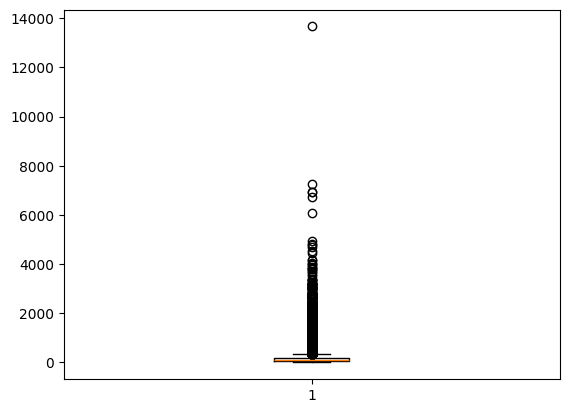

In [6]:
plt.boxplot(df_rev['payment_value'])
plt.show()

In [8]:
df_rev.dtypes

,0
order_id,object
payment_sequential,int64
payment_type,object
payment_installments,int64
payment_value,float64


In [9]:
q1 = df_rev['payment_value'].quantile(0.25)
q3 = df_rev['payment_value'].quantile(0.75)
IQR = q3-q1
print(q1,q3,IQR)
lower_fence = q1 - 1.5*(IQR)
upper_fence = q3 + 1.5*(IQR)
print("lower :",lower_fence)
print("upper :",upper_fence)



56.79 171.8375 115.04750000000001
lower : -115.78125000000003
upper : 344.40875000000005


### Feature Scaling

In [13]:
from sklearn.preprocessing import MinMaxScaler
Minmax_scaler = MinMaxScaler()
df_rev['Scaled_Payment'] = Minmax_scaler.fit_transform(df_rev[['payment_value']])
print(df_rev['Scaled_Payment'])


0         0.007269
1         0.001785
2         0.004809
3         0.007888
4         0.009401
            ...   
103881    0.026589
103882    0.007084
103883    0.003496
103884    0.027045
103885    0.014021
Name: Scaled_Payment, Length: 103886, dtype: float64


### Principle Component Analysis

In [20]:
data = {
    'Age': [20, 22, 25, 30, 32, 35, 40, 42, 45, 50],
    'Annual_Income': [25000, 30000, 35000, 50000, 55000, 60000, 80000, 85000, 90000, 100000],
    'Spending_Score': [20, 25, 30, 45, 50, 55, 70, 75, 80, 85],
    'Orders': [3, 4, 5, 8, 9, 10, 14, 15, 16, 18]
}

df_demo = pd.DataFrame(data)

print(df_demo)

   Age  Annual_Income  Spending_Score  Orders
0   20          25000              20       3
1   22          30000              25       4
2   25          35000              30       5
3   30          50000              45       8
4   32          55000              50       9
5   35          60000              55      10
6   40          80000              70      14
7   42          85000              75      15
8   45          90000              80      16
9   50         100000              85      18


In [24]:
X = df_demo[
    ['Age',
     'Annual_Income',
     'Spending_Score',
     'Orders']
]
X.shape

(10, 4)

In [26]:
from sklearn.preprocessing import StandardScaler
Scaler = StandardScaler()
X_Scaled = Scaler.fit_transform(df_demo)
print(X_Scaled)

[[-1.47090623 -1.42413799 -1.49779114 -1.42413799]
 [-1.26226705 -1.22634105 -1.27424023 -1.22634105]
 [-0.94930827 -1.0285441  -1.05068931 -1.0285441 ]
 [-0.42771032 -0.43515327 -0.38003656 -0.43515327]
 [-0.21907114 -0.23735633 -0.15648564 -0.23735633]
 [ 0.09388763 -0.03955939  0.06706528 -0.03955939]
 [ 0.61548558  0.75162838  0.73771803  0.75162838]
 [ 0.82412477  0.94942533  0.96126894  0.94942533]
 [ 1.13708354  1.14722227  1.18481986  1.14722227]
 [ 1.65868149  1.54281616  1.40837078  1.54281616]]


In [27]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_PCA = pca.fit_transform(X_Scaled)
print(X_PCA)


[[-2.90844626e+00 -2.31262362e-03]
 [-2.49456528e+00 -6.34709387e-03]
 [-2.02858021e+00  7.61078812e-02]
 [-8.39041359e-01 -2.24849749e-02]
 [-4.25160379e-01 -2.65194452e-02]
 [ 4.08246908e-02  5.59355299e-02]
 [ 1.42830520e+00 -1.05055401e-01]
 [ 1.84218618e+00 -1.09089871e-01]
 [ 2.30817125e+00 -2.66348961e-02]
 [ 3.07630616e+00  1.66400895e-01]]


In [31]:
pca.explained_variance_ratio_.sum()

np.float64(0.9992500746685463)

### It means our these 2 Features after PCA preserves 99% of variance Information equals to the 4 Features


# For Visualization

In [32]:
df_PCA = pd.DataFrame(X_PCA,columns=['PCA1','PCA2'])
df_PCA

,PCA1,PCA2
0,-2.908446,-0.002313
1,-2.494565,-0.006347
2,-2.028580,0.076108
3,-0.839041,-0.022485
4,-0.425160,-0.026519
5,0.040825,0.055936
6,1.428305,-0.105055
7,1.842186,-0.109090
8,2.308171,-0.026635
9,3.076306,0.166401


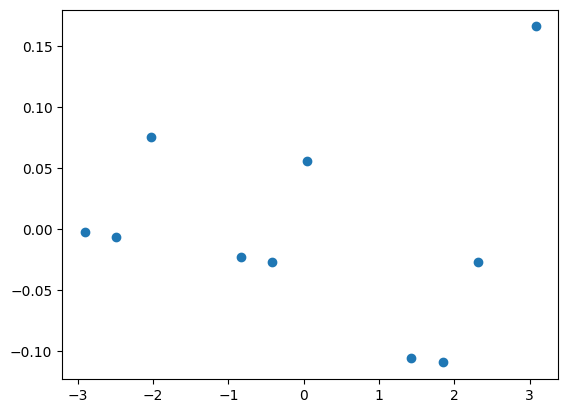

In [33]:
plt.scatter(df_PCA['PCA1'],df_PCA['PCA2'])
plt.show()

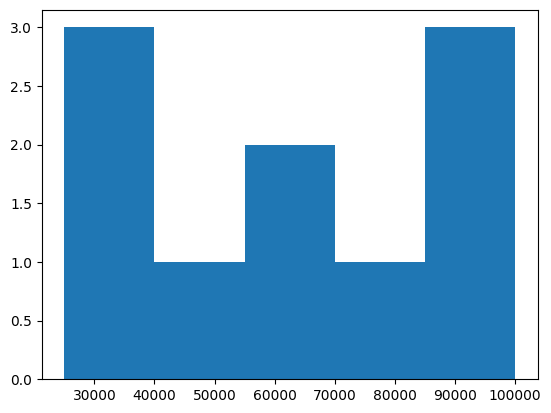

In [37]:
plt.hist(df_demo['Annual_Income'],bins=5)
plt.show()

# Activity 1

### Demo Data for Activity 1

In [4]:
data_act1 = {
    'Province': [
        'Punjab', 'Punjab', 'Punjab', 'Punjab', 'Punjab', 'Punjab',
        'Sindh', 'Sindh', 'Sindh', 'Sindh', 'Sindh', 'Sindh',
        'Khyber Pakhtunkhwa', 'Khyber Pakhtunkhwa', 'Khyber Pakhtunkhwa',
        'Khyber Pakhtunkhwa', 'Khyber Pakhtunkhwa', 'Khyber Pakhtunkhwa',
        'Balochistan', 'Balochistan', 'Balochistan', 'Balochistan',
        'Balochistan', 'Balochistan'
    ],

    'Population_millions': [
        127.7, 129.1, 126.8, 131.2, np.nan, 128.5,
        55.7, 56.8, 54.9, 58.2, 55.1, np.nan,
        40.9, 41.5, 39.8, 42.3, 40.5, 41.1,
        14.9, 15.2, 14.5, 16.1, np.nan, 15.0
    ],

    'Literacy_Rate': [
        66.2, 65.5, 67.1, 66.8, 64.9, np.nan,
        57.5, 58.2, 56.8, np.nan, 57.9, 58.5,
        51.1, 52.0, 50.4, 53.2, np.nan, 51.7,
        42.0, 41.2, 43.1, 44.0, 42.5, np.nan
    ],

    'Region': [
        'East', 'East', 'East', 'East', 'East', 'East',
        'South', 'South', 'South', 'South', 'South', 'South',
        'North', 'North', 'North', 'North', 'North', 'North',
        'West', 'West', 'West', 'West', 'West', 'West'
    ]
}

df_act1 = pd.DataFrame(data_act1)

df_act1

,Province,Population_millions,Literacy_Rate,Region
0,Punjab,127.7,66.2,East
1,Punjab,129.1,65.5,East
2,Punjab,126.8,67.1,East
3,Punjab,131.2,66.8,East
4,Punjab,NaN,64.9,East
5,Punjab,128.5,NaN,East
6,Sindh,55.7,57.5,South
7,Sindh,56.8,58.2,South
8,Sindh,54.9,56.8,South
9,Sindh,58.2,NaN,South


### Preprocessing Start from Here..

### Missing Values

In [9]:
df_act1.isna().any(axis=1).sum()

np.int64(7)

### Total Nulls Rows

In [11]:
df_act1[df_act1.isna().any(axis=1)]

,Province,Population_millions,Literacy_Rate,Region
4,Punjab,NaN,64.9,East
5,Punjab,128.5,NaN,East
9,Sindh,58.2,NaN,South
11,Sindh,NaN,58.5,South
16,Khyber Pakhtunkhwa,40.5,NaN,North
22,Balochistan,NaN,42.5,West
23,Balochistan,15.0,NaN,West


### Lets fill Literacy Rate nulls with Mean of that Province Only

In [13]:
df_act1['Literacy_Rate'] = df_act1['Literacy_Rate'].fillna(df_act1.groupby('Province')['Literacy_Rate'].transform('mean'))

### This Time we Drop Only

In [14]:
df_act1 = df_act1.dropna()

In [15]:
df_act1

,Province,Population_millions,Literacy_Rate,Region
0,Punjab,127.7,66.20,East
1,Punjab,129.1,65.50,East
2,Punjab,126.8,67.10,East
3,Punjab,131.2,66.80,East
5,Punjab,128.5,66.10,East
6,Sindh,55.7,57.50,South
7,Sindh,56.8,58.20,South
8,Sindh,54.9,56.80,South
9,Sindh,58.2,57.78,South
10,Sindh,55.1,57.90,South


### Here One Hot Encoding is used because Region has not Order


In [16]:
df_act1 = pd.get_dummies(df_act1,columns=['Region'],dtype='int')

In [17]:
df_act1

,Province,Population_millions,Literacy_Rate,Region_East,Region_North,Region_South,Region_West
0,Punjab,127.7,66.20,1,0,0,0
1,Punjab,129.1,65.50,1,0,0,0
2,Punjab,126.8,67.10,1,0,0,0
3,Punjab,131.2,66.80,1,0,0,0
5,Punjab,128.5,66.10,1,0,0,0
6,Sindh,55.7,57.50,0,0,1,0
7,Sindh,56.8,58.20,0,0,1,0
8,Sindh,54.9,56.80,0,0,1,0
9,Sindh,58.2,57.78,0,0,1,0
10,Sindh,55.1,57.90,0,0,1,0


### Visualization

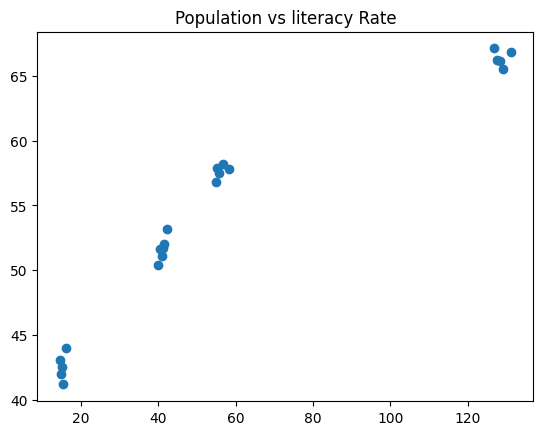

In [18]:
plt.scatter(df_act1['Population_millions'],df_act1['Literacy_Rate'])
plt.title("Population vs literacy Rate")
plt.show()

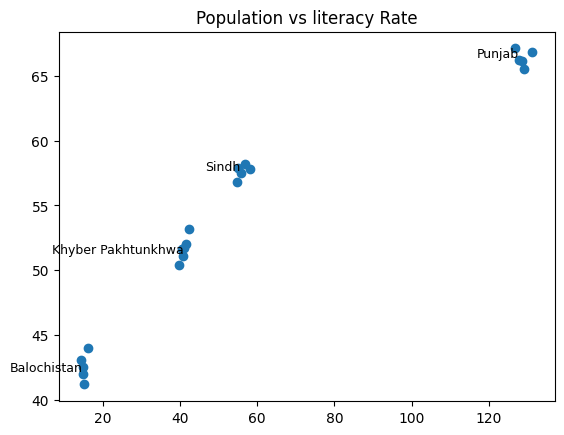

In [27]:
plt.scatter(df_act1['Population_millions'],df_act1['Literacy_Rate'])
plt.title("Population vs literacy Rate")
# Drop Duplicates Occurences of Provinces
for index,row in df_act1.drop_duplicates(subset=['Province']).iterrows():
  plt.text(
  x = row['Population_millions'],
  y = row['Literacy_Rate'],
  s = row['Province'],
  fontsize = 9,
  ha = 'right',
  va = 'bottom'
  )
plt.show()

### Outliars



{'whiskers': [<matplotlib.lines.Line2D at 0x788882f43ed0>,
 'caps': [<matplotlib.lines.Line2D at 0x78888311c190>,
 'boxes': [<matplotlib.lines.Line2D at 0x788882f43d90>],
 'medians': [<matplotlib.lines.Line2D at 0x78888311c410>],
 'fliers': [<matplotlib.lines.Line2D at 0x78888311c550>],
 'means': []}

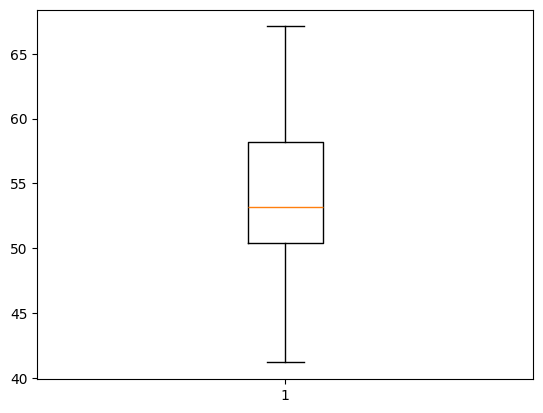

In [29]:
plt.boxplot(df_act1['Literacy_Rate'])

# Activity 2

### Demo Data for Students

In [44]:
data_std = {
    'ID': range(1, 101),
    'Math': np.random.randint(40, 101, 100).astype(float),
    'Science': np.random.randint(40, 101, 100).astype(float),
    'English': np.random.randint(40, 101, 100).astype(float),
    'Grade': np.random.choice(['A', 'B', 'C'], 100)
}
df_std = pd.DataFrame(data_std)
df_std

,ID,Math,Science,English,Grade
0,1,48.0,86.0,49.0,A
1,2,44.0,94.0,66.0,B
2,3,71.0,82.0,98.0,B
3,4,70.0,43.0,60.0,C
4,5,88.0,41.0,40.0,B
...,...,...,...,...,...
95,96,80.0,84.0,71.0,C
96,97,80.0,67.0,60.0,A
97,98,81.0,61.0,84.0,B
98,99,45.0,50.0,46.0,B


### Here we used Label Encoding for Grades


In [45]:
from sklearn.preprocessing import LabelEncoder
label_encod = LabelEncoder()
df_std['Grade'] = label_encod.fit_transform(df_std['Grade'])

### Histogram

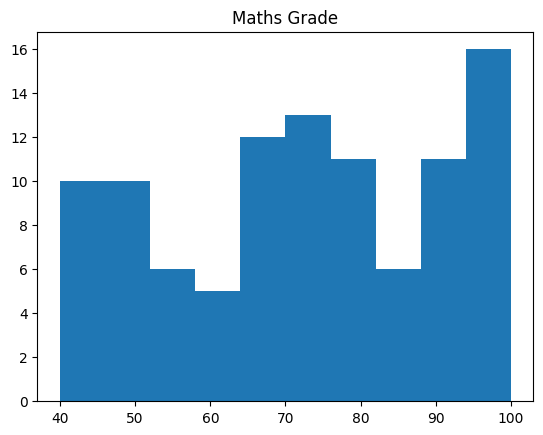

In [46]:
plt.hist(df_std['Math'],bins=10)
plt.title('Maths Grade')
plt.show()

### For Outliars in Total Score let we First Sum Student wise Numbers

In [47]:
df_std['Total'] = df_std.drop(columns=['ID','Grade']).select_dtypes(include='number').sum(axis=1)

In [48]:
df_std

,ID,Math,Science,English,Grade,Total
0,1,48.0,86.0,49.0,0,183.0
1,2,44.0,94.0,66.0,1,204.0
2,3,71.0,82.0,98.0,1,251.0
3,4,70.0,43.0,60.0,2,173.0
4,5,88.0,41.0,40.0,1,169.0
...,...,...,...,...,...,...
95,96,80.0,84.0,71.0,2,235.0
96,97,80.0,67.0,60.0,0,207.0
97,98,81.0,61.0,84.0,1,226.0
98,99,45.0,50.0,46.0,1,141.0


### Box Plot


{'whiskers': [<matplotlib.lines.Line2D at 0x788876741450>,
 'caps': [<matplotlib.lines.Line2D at 0x7888767416d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x788876741310>],
 'medians': [<matplotlib.lines.Line2D at 0x788876741950>],
 'fliers': [<matplotlib.lines.Line2D at 0x788876741a90>],
 'means': []}

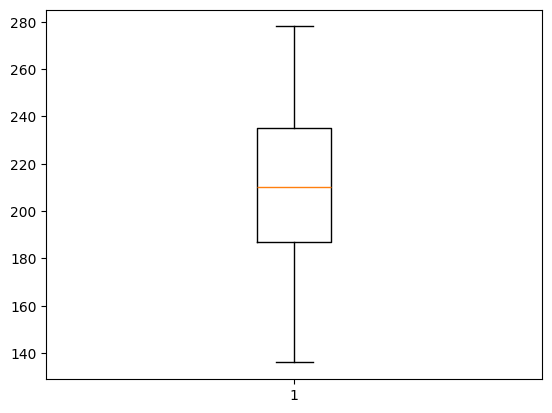

In [50]:
plt.boxplot(df_std['Total'])

# Activity 3

In [53]:
url = 'https://raw.githubusercontent.com/datasets/covid-19/master/data/time-series-19-covid-combined.csv'
data_act3 = pd.read_csv(url)
df_act3 = pd.DataFrame(data_act3)


In [54]:
df_act3

,Date,Country/Region,Province/State,Confirmed,Recovered,Deaths
0,2020-01-22,Afghanistan,NaN,0,0.0,0
1,2020-01-23,Afghanistan,NaN,0,0.0,0
2,2020-01-24,Afghanistan,NaN,0,0.0,0
3,2020-01-25,Afghanistan,NaN,0,0.0,0
4,2020-01-26,Afghanistan,NaN,0,0.0,0
...,...,...,...,...,...,...
231739,2022-04-12,Zimbabwe,NaN,247094,0.0,5460
231740,2022-04-13,Zimbabwe,NaN,247160,0.0,5460
231741,2022-04-14,Zimbabwe,NaN,247208,0.0,5462
231742,2022-04-15,Zimbabwe,NaN,247237,0.0,5462


### Only Pakistan

In [57]:
df_Pak = df_act3[df_act3['Country/Region']== 'Pakistan']

In [58]:
df_Pak

,Date,Country/Region,Province/State,Confirmed,Recovered,Deaths
168912,2020-01-22,Pakistan,NaN,0,0.0,0
168913,2020-01-23,Pakistan,NaN,0,0.0,0
168914,2020-01-24,Pakistan,NaN,0,0.0,0
168915,2020-01-25,Pakistan,NaN,0,0.0,0
168916,2020-01-26,Pakistan,NaN,0,0.0,0
...,...,...,...,...,...,...
169723,2022-04-12,Pakistan,NaN,1526829,0.0,30362
169724,2022-04-13,Pakistan,NaN,1526952,0.0,30362
169725,2022-04-14,Pakistan,NaN,1526952,0.0,30362
169726,2022-04-15,Pakistan,NaN,1527151,0.0,30363


### Handling Missing Values

In [60]:
df_Pak[df_Pak.isna().any(axis=1)]

,Date,Country/Region,Province/State,Confirmed,Recovered,Deaths
168912,2020-01-22,Pakistan,NaN,0,0.0,0
168913,2020-01-23,Pakistan,NaN,0,0.0,0
168914,2020-01-24,Pakistan,NaN,0,0.0,0
168915,2020-01-25,Pakistan,NaN,0,0.0,0
168916,2020-01-26,Pakistan,NaN,0,0.0,0
...,...,...,...,...,...,...
169723,2022-04-12,Pakistan,NaN,1526829,0.0,30362
169724,2022-04-13,Pakistan,NaN,1526952,0.0,30362
169725,2022-04-14,Pakistan,NaN,1526952,0.0,30362
169726,2022-04-15,Pakistan,NaN,1527151,0.0,30363


In [61]:
df_Pak['Province/State'].unique()

array([nan], dtype=object)

In [62]:
df_Pak['Province/State'] = df_Pak['Province/State'].fillna('Not Given')

/tmp/ipykernel_2122/3845524638.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Pak['Province/State'] = df_Pak['Province/State'].fillna('Not Given')


In [63]:
df_Pak

,Date,Country/Region,Province/State,Confirmed,Recovered,Deaths
168912,2020-01-22,Pakistan,Not Given,0,0.0,0
168913,2020-01-23,Pakistan,Not Given,0,0.0,0
168914,2020-01-24,Pakistan,Not Given,0,0.0,0
168915,2020-01-25,Pakistan,Not Given,0,0.0,0
168916,2020-01-26,Pakistan,Not Given,0,0.0,0
...,...,...,...,...,...,...
169723,2022-04-12,Pakistan,Not Given,1526829,0.0,30362
169724,2022-04-13,Pakistan,Not Given,1526952,0.0,30362
169725,2022-04-14,Pakistan,Not Given,1526952,0.0,30362
169726,2022-04-15,Pakistan,Not Given,1527151,0.0,30363


### Plot Cases

### Cases Increased with Time

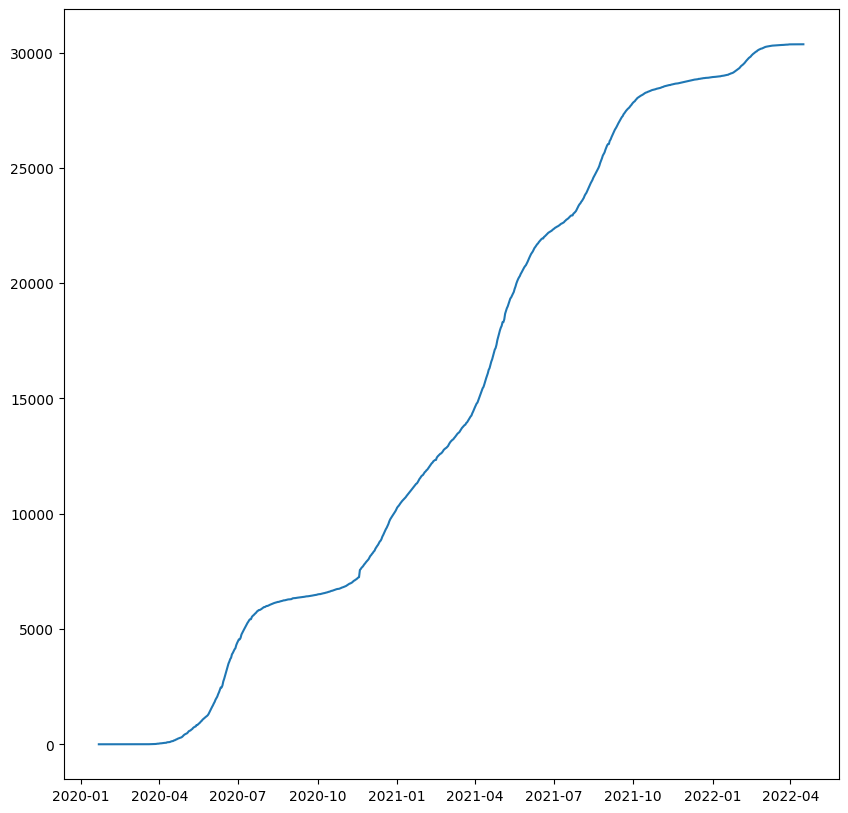

In [70]:
df_Pak['Date'] = pd.to_datetime(df_Pak['Date'])
df_Pak = df_Pak.sort_values('Date')
plt.figure(figsize=(10,10))
plt.plot(df_Pak['Date'],df_Pak['Deaths'])
plt.show()

### Highest Deaths Rate

In [75]:
df_Pak[df_Pak['Confirmed']== df_Pak['Confirmed'].max()]

,Date,Country/Region,Province/State,Confirmed,Recovered,Deaths
169727,2022-04-16,Pakistan,Not Given,1527248,0.0,30363


### Outliars

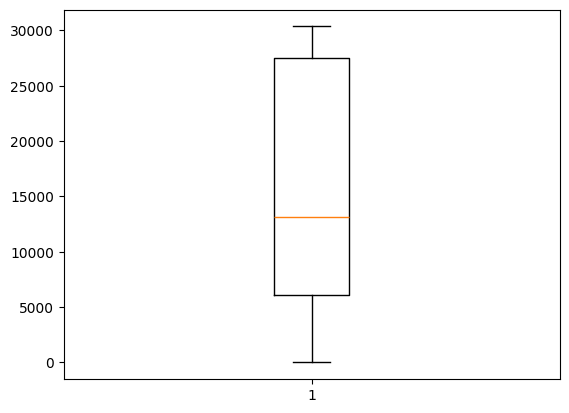

In [76]:
plt.boxplot(df_Pak['Deaths'])
plt.show()

# Activity 4

In [77]:
atten = pd.read_json('/content/attendance.json')
df_atten = pd.DataFrame(atten)
df_atten

,Name,Attendance
0,Student_1,86
1,Student_2,56
2,Student_3,70
3,Student_4,58
4,Student_5,88
5,Student_6,67
6,Student_7,53
7,Student_8,74
8,Student_9,63
9,Student_10,99


In [79]:
std = pd.read_csv('/content/students.csv')
df_std1 = pd.DataFrame(std)
df_std1

,Name,Marks
0,Student_1,78
1,Student_2,91
2,Student_3,68
3,Student_4,54
4,Student_5,82
5,Student_6,47
6,Student_7,60
7,Student_8,78
8,Student_9,97
9,Student_10,58


In [80]:
extra = pd.read_excel('/content/extra.xlsx')
df_extra = pd.DataFrame(extra)
df_extra

,Name,Bonus
0,Student_1,4
1,Student_2,7
2,Student_3,9
3,Student_4,8
4,Student_5,8
5,Student_6,0
6,Student_7,8
7,Student_8,6
8,Student_9,8
9,Student_10,7


### Merge all of these


In [86]:
All_Std_Atten = pd.merge(df_std1,df_atten,on='Name',how='inner')


In [87]:
All_Now = pd.merge(All_Std_Atten,df_extra,on='Name',how='inner')

In [88]:
All_Now

,Name,Marks,Attendance,Bonus
0,Student_1,78,86,4
1,Student_2,91,56,7
2,Student_3,68,70,9
3,Student_4,54,58,8
4,Student_5,82,88,8
5,Student_6,47,67,0
6,Student_7,60,53,8
7,Student_8,78,74,6
8,Student_9,97,63,8
9,Student_10,58,99,7


### Scatter Plot

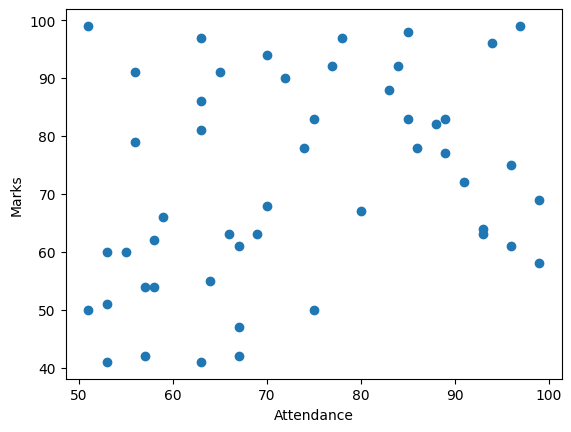

In [90]:
plt.scatter(All_Now['Attendance'],All_Now['Marks'])
plt.xlabel('Attendance')
plt.ylabel('Marks')
plt.show()

### Using Comprehensive For LOOP

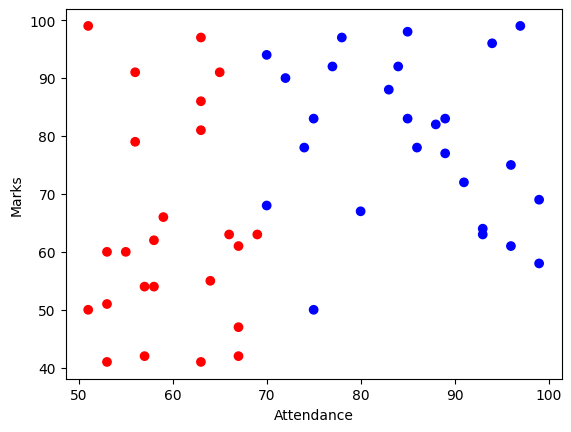

In [91]:
Colors = ['Red' if attend < 70 else 'Blue' for attend in All_Now['Attendance']]
plt.scatter(All_Now['Attendance'],All_Now['Marks'],c=Colors)
plt.xlabel('Attendance')
plt.ylabel('Marks')
plt.show()